
#***TELECOM X***🛰️📡

#**Introducción**

*En la actualidad, la retención de clientes se ha convertido en un factor clave para la sostenibilidad y competitividad de las empresas y Telecom X enfrenta una tasa de evasión de clientes (churn) considerable, y representa no solo una pérdida directa de ingresos, sino también un indicador de posibles áreas de mejora en sus servicios y estrategias comerciales.*

*El objetivo principal de este análisis es identificar y comprender los factores que influyen en la cancelación del servicio por parte de los clientes. Por eso, se realiza un proceso de exploración, limpieza y análisis de los datos utilizando Python y sus principales bibliotecas de análisis de datos. A través de este estudio, se busca detectar patrones relevantes relacionados con características: tipo de contrato, servicios contratados y comportamiento de consumo.*

*Los resultados obtenidos servirán como base para que el equipo de Data Science pueda desarrollar conclusiones para prevenir mas evasión y proponer estrategias orientadas a mejorar la experiencia del cliente, y fortalecer la fidelización a largo plazo.*

#📌 Extracción

In [190]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [191]:
datos = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [192]:
#primero leemos los datos que tenemos
#identificamos si nuestro dataframe tiene alguna estructura no deseada
df_anidado= pd.read_json(datos)
df_anidado.head(2)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [193]:
#normalizamos nuestro data frame ya que existen estructuras anidadas
df_normalizado = pd.json_normalize(df_anidado.to_dict('records'))


In [194]:
#visualizamos nuestro data frame normalizado
# y normalizamos los nombres
# Prefijos que eliminaremos
prefijos = ['customer.', 'phone.', 'internet.', 'account.', 'Charges.']
for prefijo in prefijos:
    df_normalizado.columns = df_normalizado.columns.str.replace(prefijo, '')

df_normalizado.head(2)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4


#🔧 Transformación

In [195]:
#vemos la informacion preliminar de nuestro data frame
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [196]:
#convertimos el tipo de dato segun sea el correcto en cada columna
df_normalizado['Total'] = pd.to_numeric(df_normalizado['Total'], errors='coerce')

In [197]:
#visualizamos los cambios
#vemos a simple vista si existen valores nulos
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [198]:
#eliminamos los datos nulos, ya que si existen en la ultima columna
df = df_normalizado.dropna()
# Creamos una máscara para ver y eliminar si existen cadenas vacias
mascara = (df != '').all(axis=1)

# Filtramos el DataFrame
df = df[mascara]

# Revisamos que todo esté bien
print(df.shape)

(7032, 21)


In [199]:
#vemos si existe algun valor no deseado
df['Total'].isna().sum()

np.int64(0)

In [200]:
df.sample(2)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
6877,9489-JMTTN,No,Female,0,Yes,Yes,72,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),89.75,6595.90
1137,1612-EOHDH,Yes,Female,0,No,No,1,Yes,No,DSL,...,No,No,No,No,No,Month-to-month,No,Electronic check,45.15,45.15


In [201]:
df.columns.tolist()

['customerID',
 'Churn',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Monthly',
 'Total']

In [202]:
# Diccionario de traducciones
nuevos_nombres = {
    'customerID': 'ID del cliente',
    'Churn': 'Cancelacion',
    'gender': 'Género',
    'SeniorCitizen': 'Adulto mayor',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Antigüedad en meses',
    'PhoneService': 'Servicio telefónico',
    'MultipleLines': 'Múltiples líneas',
    'InternetService': 'Servicio de internet',
    'OnlineSecurity': 'Seguridad en línea',
    'OnlineBackup': 'Respaldo en línea',
    'DeviceProtection': 'Protección del dispositivo',
    'TechSupport': 'Soporte técnico',
    'StreamingTV': 'TV en streaming',
    'StreamingMovies': 'Películas en streaming',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Facturación electrónica',
    'PaymentMethod': 'Método de pago',
    'Monthly': 'Cargo mensual',
    'Total': 'Cargos totales'
}

# Aplicamos el renombrado
df = df.rename(columns=nuevos_nombres)

# Revisamos que todo quedó bien
print(df.columns)

Index(['ID del cliente', 'Cancelacion', 'Género', 'Adulto mayor', 'Pareja',
       'Dependientes', 'Antigüedad en meses', 'Servicio telefónico',
       'Múltiples líneas', 'Servicio de internet', 'Seguridad en línea',
       'Respaldo en línea', 'Protección del dispositivo', 'Soporte técnico',
       'TV en streaming', 'Películas en streaming', 'Contrato',
       'Facturación electrónica', 'Método de pago', 'Cargo mensual',
       'Cargos totales'],
      dtype='object')


In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID del cliente              7032 non-null   object 
 1   Cancelacion                 7032 non-null   object 
 2   Género                      7032 non-null   object 
 3   Adulto mayor                7032 non-null   int64  
 4   Pareja                      7032 non-null   object 
 5   Dependientes                7032 non-null   object 
 6   Antigüedad en meses         7032 non-null   int64  
 7   Servicio telefónico         7032 non-null   object 
 8   Múltiples líneas            7032 non-null   object 
 9   Servicio de internet        7032 non-null   object 
 10  Seguridad en línea          7032 non-null   object 
 11  Respaldo en línea           7032 non-null   object 
 12  Protección del dispositivo  7032 non-null   object 
 13  Soporte técnico             7032 non-n

In [204]:
df.head(3)

,ID del cliente,Cancelacion,Género,Adulto mayor,Pareja,Dependientes,Antigüedad en meses,Servicio telefónico,Múltiples líneas,Servicio de internet,...,Respaldo en línea,Protección del dispositivo,Soporte técnico,TV en streaming,Películas en streaming,Contrato,Facturación electrónica,Método de pago,Cargo mensual,Cargos totales
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [205]:
#las columnas que sean necesarias, las convertimos en binario YES = 1, NO = 0
map_binario = {'No': 0, 'Yes': 1}

cols_binarias = [
    'Pareja', 'Cancelacion', 'Dependientes',
    'Servicio telefónico', 'Facturación electrónica'
]

df[cols_binarias] = (
    df[cols_binarias]
        .replace(map_binario)
        .infer_objects(copy=False)
        .astype('Int64')
)

df.head(2)

/tmp/ipykernel_753/2443597127.py:11: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,ID del cliente,Cancelacion,Género,Adulto mayor,Pareja,Dependientes,Antigüedad en meses,Servicio telefónico,Múltiples líneas,Servicio de internet,...,Respaldo en línea,Protección del dispositivo,Soporte técnico,TV en streaming,Películas en streaming,Contrato,Facturación electrónica,Método de pago,Cargo mensual,Cargos totales
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.3
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.4


#📊 Carga y análisis

In [206]:
df.describe()

,Cancelacion,Adulto mayor,Pareja,Dependientes,Antigüedad en meses,Servicio telefónico,Facturación electrónica,Cargo mensual,Cargos totales
count,7032.0,7032.000000,7032.0,7032.0,7032.000000,7032.0,7032.0,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362
min,0.0,0.000000,0.0,0.0,1.000000,0.0,0.0,18.250000,18.800000
25%,0.0,0.000000,0.0,0.0,9.000000,1.0,0.0,35.587500,401.450000
50%,0.0,0.000000,0.0,0.0,29.000000,1.0,1.0,70.350000,1397.475000
75%,1.0,0.000000,1.0,1.0,55.000000,1.0,1.0,89.862500,3794.737500
max,1.0,1.000000,1.0,1.0,72.000000,1.0,1.0,118.750000,8684.800000


**Que significa esto?**
- el 26.5% de los clientes cancela, pero tenemos el 73.4 que no cancela.
- el 16% son adultos mayores.
- el 48% tiene pareja.
- En la antiguedad en meses vemos que el promedio es de 32.4%
- Hay desviación estandar de 36.9% para los adultos mayores de 60 años, es muy desigual.


In [207]:
#vamos a evaluar variables conjuntas, para ver si se relacionan y se distribuyen.
#analizamos primero la Cancelacion y el total de clientes

conteo_cancelacion = df['Cancelacion'].value_counts().sort_index()
porcentaje_cancelacion = df['Cancelacion'].value_counts(normalize=True).sort_index() * 100

df_cancelacion = pd.DataFrame({
    'Cancelación': ['No cancelado', 'Canceló'],
    'Clientes': conteo_cancelacion.values,
    'Porcentaje': porcentaje_cancelacion.values
})


fig2 = px.pie(
    df_cancelacion,
    names='Cancelación',
    values='Porcentaje',
    hole=0.45,
    title='Distribucion de evacion de los clientes'
)

fig2.update_traces(textinfo='percent+label')
fig2.update_layout(template='plotly_white')

fig2.show()


en la distribución de clientes se muestra que aproximadamente el 26–27% ha cancelado el servicio, mientras que cerca del 73–74% permanece activo. Aunque la mayoría de los clientes no presenta cancelación, la proporción de bajas es significativa, lo que justifica un análisis más profundo de los factores asociados al churn.

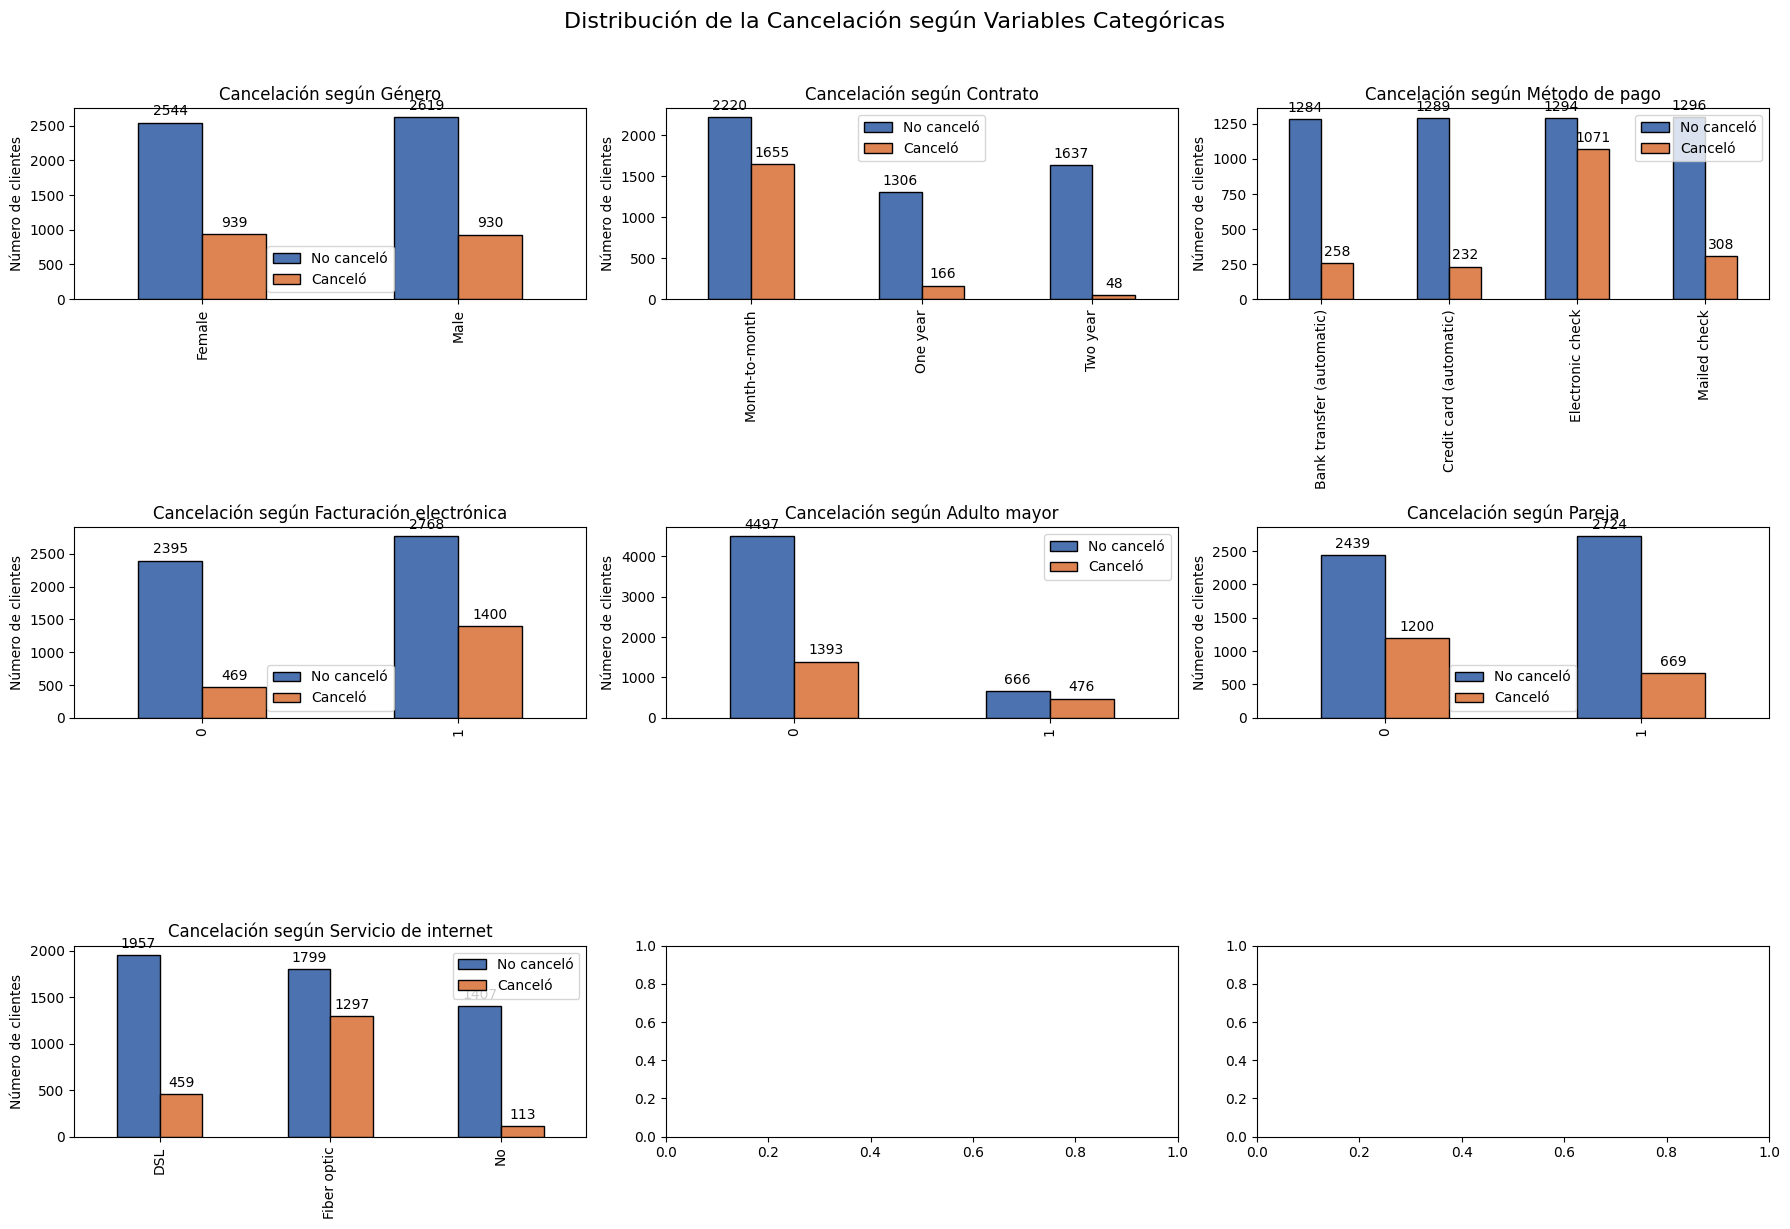

In [208]:
#viendo esos datos, vamos a hacer un analisis general de variables categoricas.

colores = {0: '#4C72B0', 1: '#DD8452'}  # azul = No, rojo = Sí

variables_categoricas = [
    'Género',
    'Contrato',
    'Método de pago',
    'Facturación electrónica',
    'Adulto mayor',
    'Pareja','Servicio de internet'
]

fig, axes = plt.subplots(3,3, figsize=(18, 12))
axes = axes.flatten()

for ax, var in zip(axes, variables_categoricas):
    tabla = (
        df.groupby([var, 'Cancelacion'])
        .size()
        .unstack(fill_value=0)
    )

    tabla.plot(
        kind='bar',
        ax=ax,
        color=[colores[0], colores[1]],
        edgecolor='black'
    )

    ax.set_title(f'Cancelación según {var}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Número de clientes')
    ax.legend(['No canceló', 'Canceló'])

    # Números encima de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.suptitle(
    'Distribución de la Cancelación según Variables Categóricas',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


Observaciones
- Tanto hombres como mujeres muestran cifras muy similares en cuanto a cancelaciones.
- Los clientes menores de 60 años concentran la mayor proporción de bajas.
- Quienes no tienen pareja registran más cancelaciones que aquellos que sí la tienen.
- Los usuarios sin dependientes presentan más casos de abandono que los que cuentan con dependientes.
- El servicio de internet por fibra óptica se asocia con un elevado número de cancelaciones.
- Los contratos de tipo mensual reflejan una tasa de cancelación considerablemente alta.
- El pago mediante cheque electrónico se vincula con un mayor nivel de bajas.
Resumen de tasas de abandono por servicios:



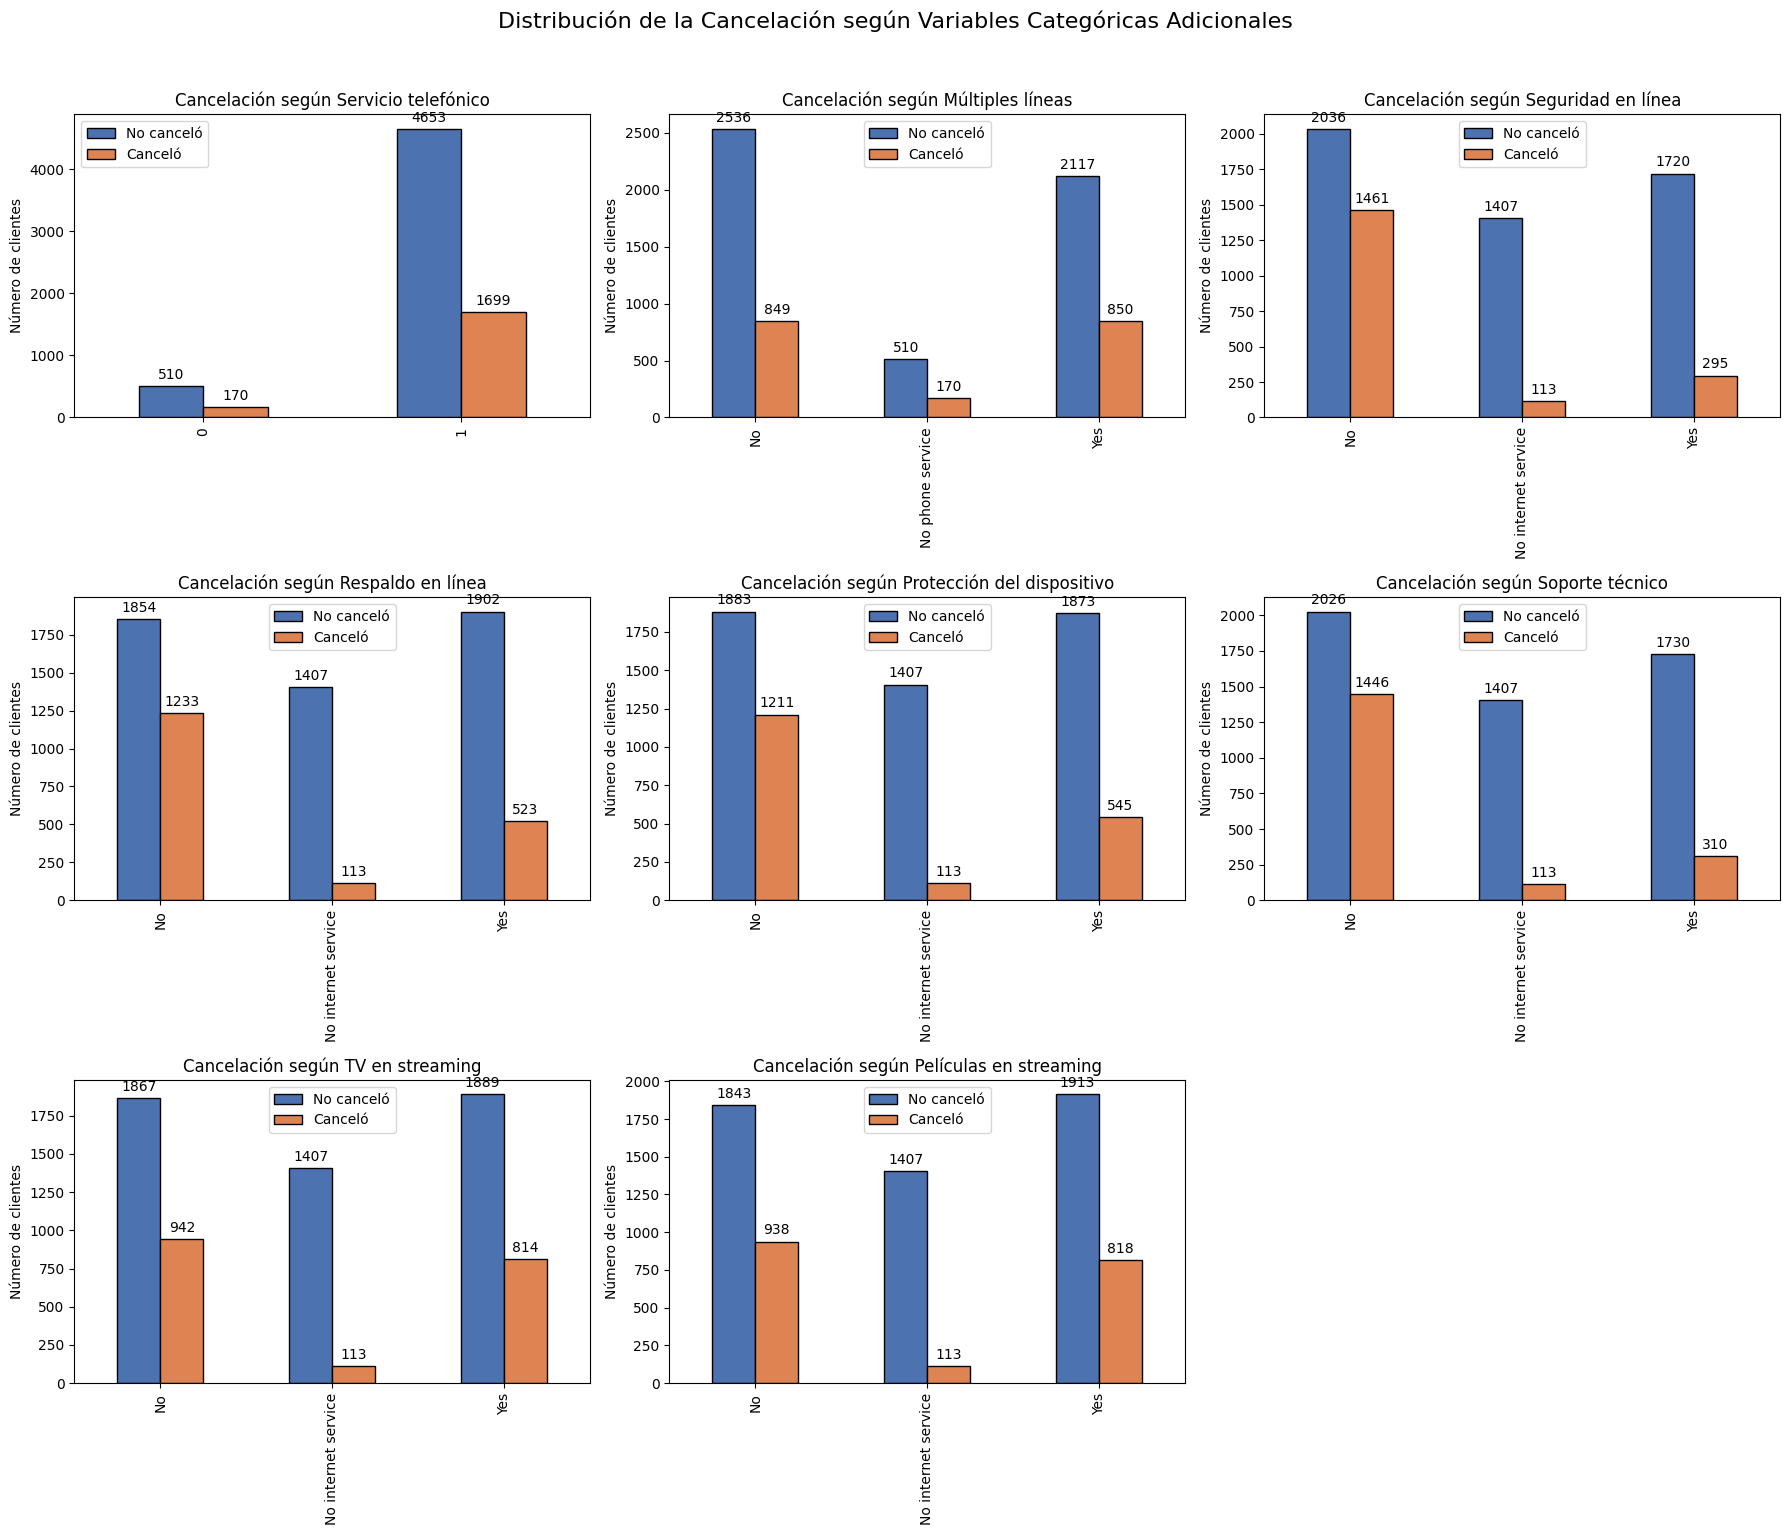

In [209]:

# Nuevas variables categóricas a analizar
variables_categóricas = [
    'Servicio telefónico',
    'Múltiples líneas',
    'Seguridad en línea',
    'Respaldo en línea',
    'Protección del dispositivo',
    'Soporte técnico',
    'TV en streaming',
    'Películas en streaming'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))  # 3 filas, 3 columnas
axes = axes.flatten()

for i, var_name in enumerate(variables_categóricas):
    if i < len(axes): # Ensure we don't go out of bounds if variables_categóricas > axes
        current_ax = axes[i] # Get the current Axes object from the flattened array

        tabla = (
            df.groupby([var_name, 'Cancelacion'])
            .size()
            .unstack(fill_value=0)
        )

        tabla.plot(
            kind='bar',
            ax=current_ax, # Use the actual Axes object here
            color=['#4C72B0', '#DD8452'],  # Colores consistentes
            edgecolor='black'
        )

        current_ax.set_title(f'Cancelación según {var_name}', fontsize=12) # Use var_name for title
        current_ax.set_xlabel('')
        current_ax.set_ylabel('Número de clientes')
        current_ax.legend(['No canceló', 'Canceló'])
        for container in current_ax.containers:
            current_ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

# Ocultar la celda extra si es necesario
for j in range(len(variables_categóricas), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribución de la Cancelación según Variables Categóricas Adicionales', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- Los usuarios que cuentan con servicio telefónico muestran una elevada proporción de cancelaciones.
- Tanto quienes poseen múltiples líneas como quienes no las tienen presentan cifras de bajas bastante similares.
- La ausencia del servicio de seguridad en linea muestra muchas cancelaciones.
- Los clientes sin respaldo en línea registran más casos de abandono que los que sí lo tienen.
- La falta de protección de dispositivos se asocia con un alto nivel de cancelaciones.
- Los clientes que no disponen de soporte técnico reflejan una tasa de cancelación significativa.
- El servicio de televisión en streaming, tanto para quienes lo tienen como para quienes no, muestra prácticamente los mismos niveles de cancelación.
- Lo mismo ocurre con el servicio de películas en streaming: las tasas de bajas son muy parecidas entre quienes lo contratan y quienes no.


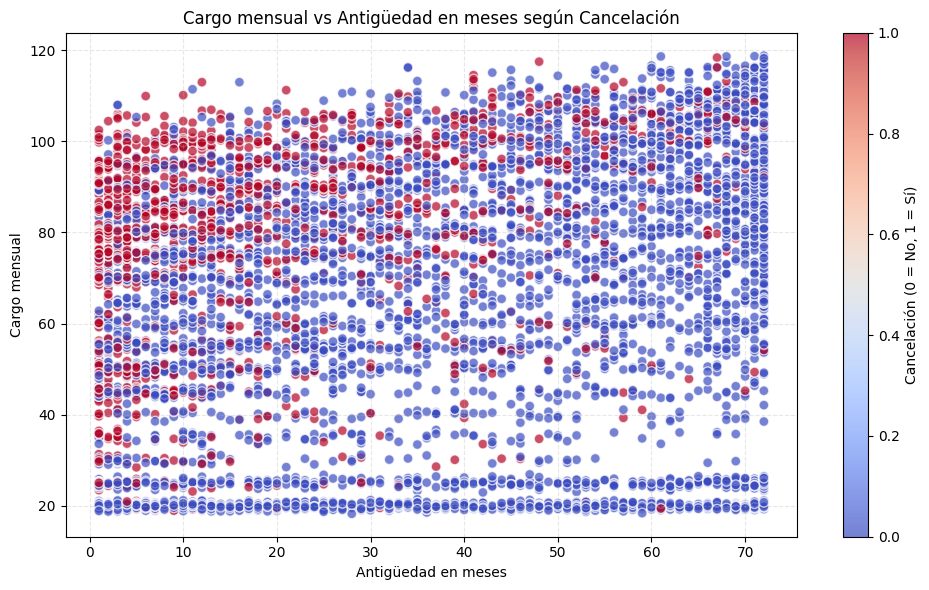

In [210]:
# Scatter plot de Cargo mensual vs Antigüedad en meses
plt.figure(figsize=(10, 6))

# Coloreamos los puntos según la cancelación
scatter = plt.scatter(
    df['Antigüedad en meses'],
    df['Cargo mensual'],
    c=df['Cancelacion'],
    cmap='coolwarm',  # Colores: azul (no canceló) / rojo (sí canceló)
    alpha=0.7,
    edgecolors='w',  # Borde blanco para resaltar
    s=50  # Tamaño de los puntos
)

plt.colorbar(scatter, label='Cancelación (0 = No, 1 = Sí)')
plt.title('Cargo mensual vs Antigüedad en meses según Cancelación')
plt.xlabel('Antigüedad en meses')
plt.ylabel('Cargo mensual')

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

- hay un alto nivel de cancelaciones en los primeros meses, debido al alto precio

/tmp/ipykernel_753/2512338177.py:14: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_753/2512338177.py:14: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_753/2512338177.py:14: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



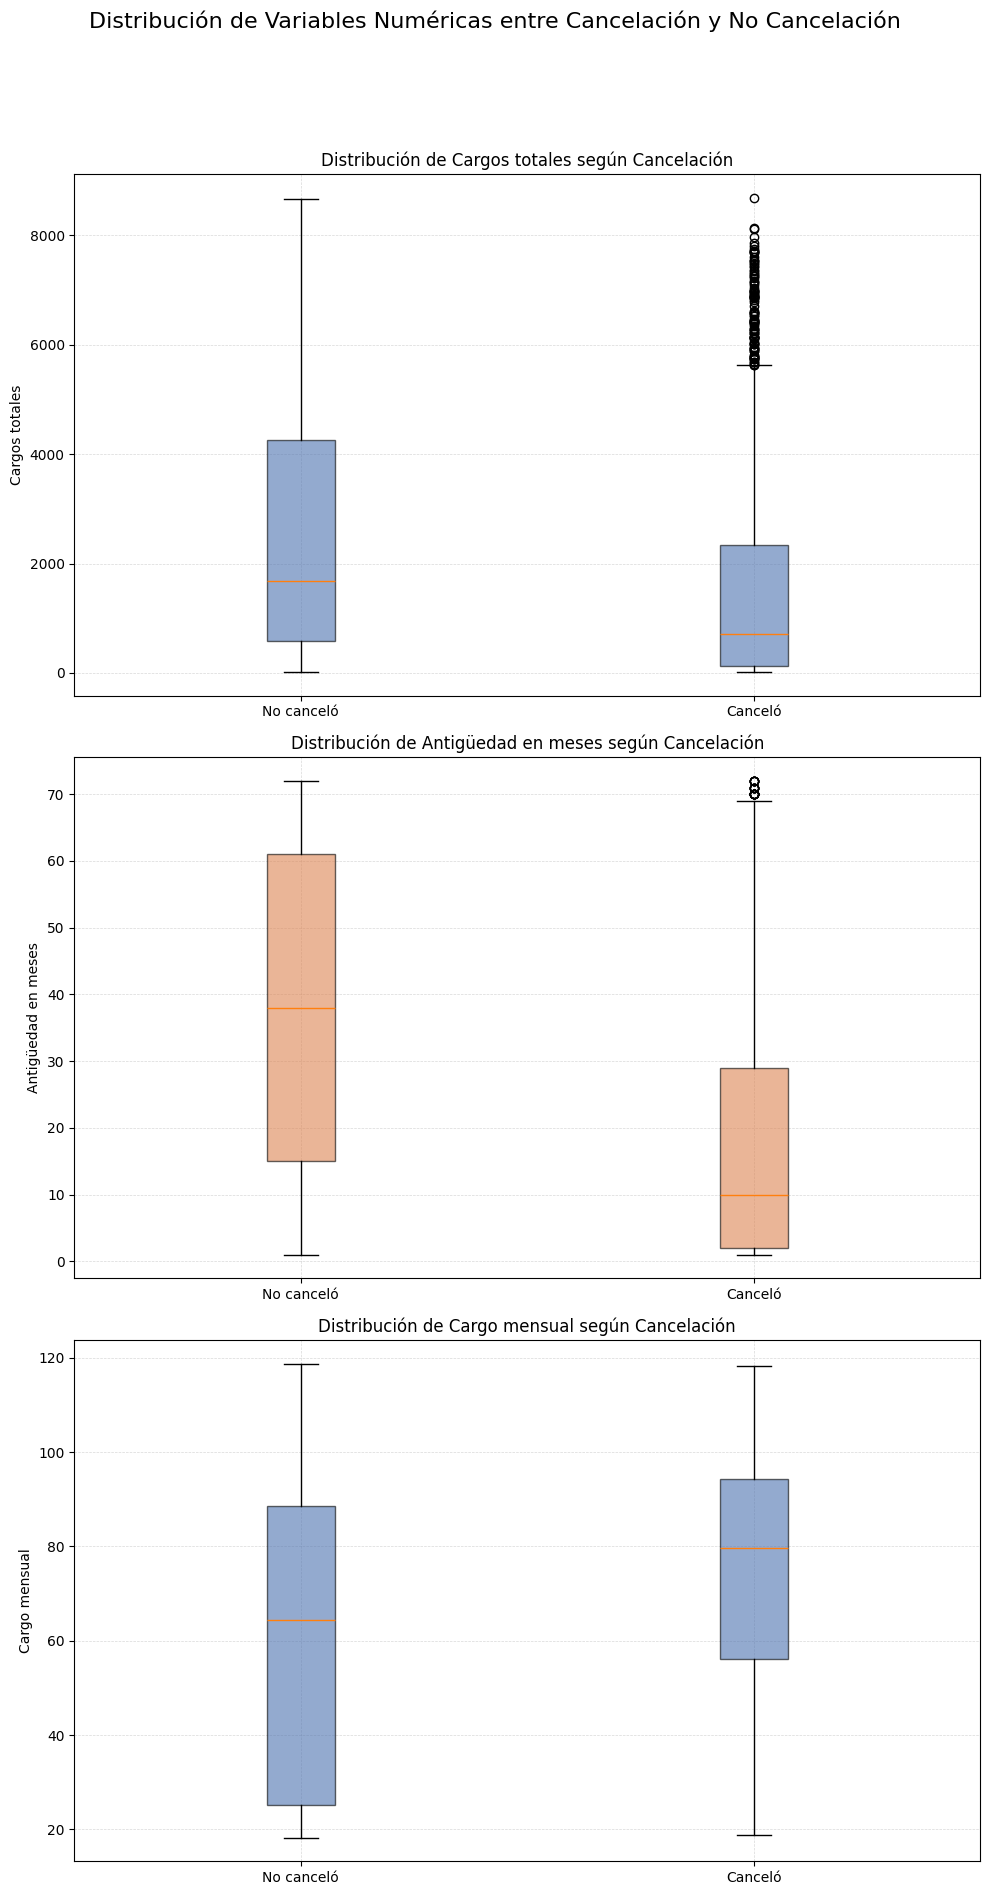

In [211]:
# Variables numéricas a analizar
variables_numericas = [
    'Cargos totales',
    'Antigüedad en meses',
    'Cargo mensual'
]

fig, axes = plt.subplots(len(variables_numericas), 1, figsize=(10, 6 * len(variables_numericas)))

if len(variables_numericas) == 1:
    axes = [axes]

for ax, var in zip(axes, variables_numericas):
    ax.boxplot(
        [df[df['Cancelacion'] == 0][var],
         df[df['Cancelacion'] == 1][var]],
        labels=['No canceló', 'Canceló'],
        patch_artist=True,
        boxprops=dict(facecolor='#4C72B0' if var == 'Cargos totales' else ('#DD8452' if var != 'Cargo mensual' else '#4C72B0'), alpha=0.6)
    )
    ax.set_title(f'Distribución de {var} según Cancelación', fontsize=12)
    ax.set_ylabel(var)
    ax.set_xlabel('')

    # cuadricula
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle('Distribución de Variables Numéricas entre Cancelación y No Cancelación', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

- En cuanto al tiempo de contrato, se observa que las cancelaciones se concentran en clientes con permanencias cortas.
- Respecto al valor mensual, los usuarios con cargos más elevados muestran una mayor tendencia a abandonar el servicio.
- Si analizamos el total cobrado, los clientes que se retiran lo hacen sin haber acumulado un historial de facturación significativo.


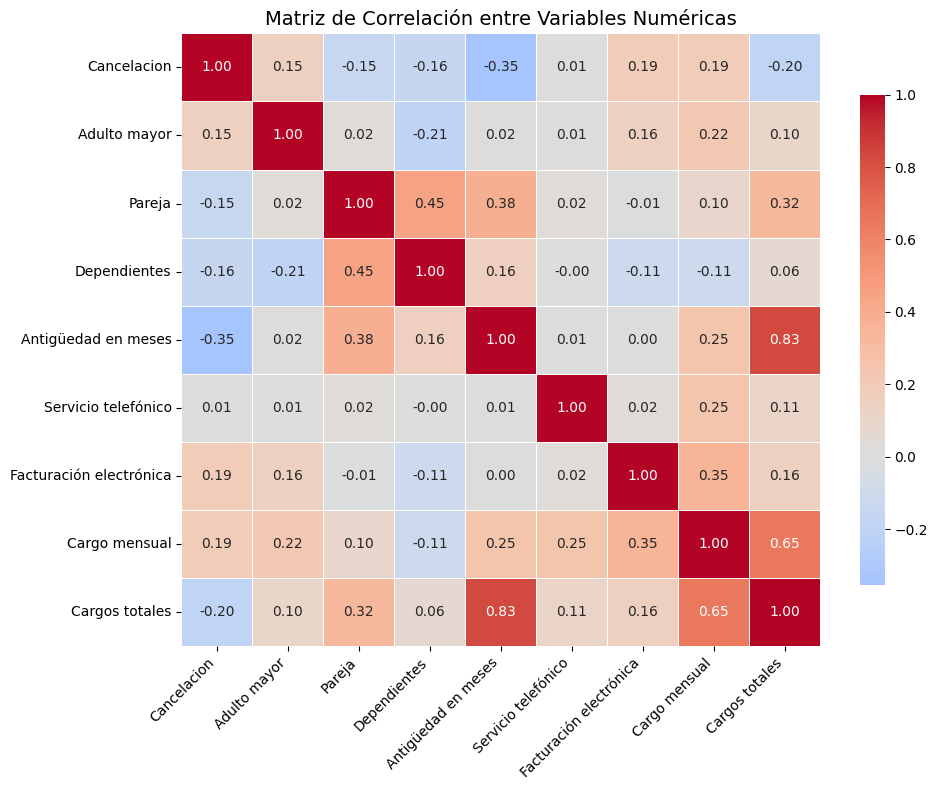

In [212]:
# Seleccionar solo variables numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

corr = df_numerico.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#📄Informe final

**Conclusiones**

- *El análisis del conjunto de datos revisados muestran un procentaje del 26.6% de personas que ya han cancelado el servicio, y es un porcenjate que debe de tomarse muy en cuenta.*

- *Para que el servicio continue en el cliente, debemos de dar un mejor servicio, ya que la mayor parte de cancelacion de los clientes es por parte de los primeros meses.*

- *Los clientes que ya llevan tiempo con el servicio con clientes estables, a comparacion de los clientes nuevos o que tienen poco tiempo de antiguedad, tienden a abandonarlo.*

- *Lo que paga el cliente en el plan mensual, es un factor que se debe de tomar muy en cuenta, ya que hay una tasa de desersion considerable por parte de los precios.*

- *El tipo de contrato mensual es el tipo de contrato que mas lleva a la desercion de clientes, es comprensible que cambiar los contratos a contratos mas largos para mantener estabilidad de los clientes no es del todo seguro, ya que se debe de estudiar el mercado y las competencias.*

- *La fibra optica ofrecida tiene consecuencias juntamente con el tiempo de asistencia tecnica para los clientes, y hay un nivel de bajas considerable*

- *Los servicios de seguridad en linea y respaldo de informacion tambien es importante, ya que los servicios que no la tienen muestran un abandono constante, esto puede significar que le puede dar valor al cliente.*

- *Los clientes que utilizan métodos de pago manuales presentan una mayor tendencia a cancelar el servicio, podemos deducir que la automatización de pagos podría contribuir a reducir el abandono.*
  

**Recomendaciones**
1. Fortalecer la etapa inicial del servicio

Implementar programas de acompañamiento para los clientes, almenos por los primeros meses, una asistencia personalizada y seguimiento respectivo..

Tener una deteccion temprana de inconformidades que el cliente tenga, y un servicio tecnico oportuno para que el cliente no tome la decision de abandonar el servicio

2. Mejorar la propuesta del contrato mensual

Mejorar el contrato mensual, hacer promociones, descuentos, u otras formas para mejorar la fidelizacion del cliente.

Hay que diseñar estrategias bien estructuradas, ya que este es el mayor problema por el cual el cliente abandona.

3. Incentivar contratos de mayor duración

Ofrecer beneficios a los clientes que pasen de contratos mensuales a planes anuales o semestrales, como buenos precios, descuentos o agregacion de otros servicios.

Persuadir al cliente para que cambie a un plan mas largo, pero sin obligar al cliente a que lo eliga, ya que el cliente tiene la libertad de decidir.

4. Ajustar la estrategia de precios

Evaluar la relación del cargo mensual y como el cliente esta satisfecho con el.

Configurar lo planes, segun el tipo de cliente su estado economico y la capacidad que este tenga para pagar.

5. Promover servicios complementarios

Crear paquetes que integren estos servicios a un costo reducido para aumentar la estabilidad de clientes con el servicio.

6. Optimizar los métodos de pago

Incentivar el metodo de pago, de manuales a automaticos, ofrecer algun tipo de descuento o promocion.

Reducir molestias por el pago de metodos manuales, por el tiempo administrativo o de gestion que se realice para verificar pagos y disminuir el tiempo.